# NLP Practice

In [42]:
%pip install nltk

%pip install scikit-learn

%pip install spacy
!python -m spacy download en_core_web_sm

%pip install wordcloud


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 2.6 MB/s eta 0:00:05
     ---- ----------------------------------- 1.6/12.8 MB 3.1 MB/s eta 0:00:04
     ------- -------------------------------- 2.4/12.8 MB 3.5 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 3.4 MB/s eta 0:00:03
     ----------- ---------------------------- 3.7/12.8 MB 3.4 MB/s eta 0:00:03
     ------------- -------------------------- 4.5/12.8 MB 3.4 MB/s eta 0:00:03
     ----------------- ---------------------- 5.5/12.8 MB 3.6 MB/s eta 0:00:03
     ------------------- -------------------- 6.3/12.8 MB 3.7 MB/s eta 0:00:02
     --------------

In [43]:

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

text = "The cat (Felis catus), also called domestic cat and house cat, is a small domesticated carnivorous mammal. It has a strong, flexible body, quick reflexes, and sharp teeth, and its night vision and sense of smell are well developed."

# word tokenaization
words = nltk.word_tokenize(text)
print("Word Tokens:", words)


# stop words
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word.lower() not in stop_words]
print("Filtered Words:", filtered_words)



Word Tokens: ['The', 'cat', '(', 'Felis', 'catus', ')', ',', 'also', 'called', 'domestic', 'cat', 'and', 'house', 'cat', ',', 'is', 'a', 'small', 'domesticated', 'carnivorous', 'mammal', '.', 'It', 'has', 'a', 'strong', ',', 'flexible', 'body', ',', 'quick', 'reflexes', ',', 'and', 'sharp', 'teeth', ',', 'and', 'its', 'night', 'vision', 'and', 'sense', 'of', 'smell', 'are', 'well', 'developed', '.']
Filtered Words: ['cat', '(', 'Felis', 'catus', ')', ',', 'also', 'called', 'domestic', 'cat', 'house', 'cat', ',', 'small', 'domesticated', 'carnivorous', 'mammal', '.', 'strong', ',', 'flexible', 'body', ',', 'quick', 'reflexes', ',', 'sharp', 'teeth', ',', 'night', 'vision', 'sense', 'smell', 'well', 'developed', '.']


[nltk_data] Downloading package punkt to C:\Users\Atousa
[nltk_data]     K\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Atousa
[nltk_data]     K\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Atousa
[nltk_data]     K\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [44]:
from nltk.tokenize import sent_tokenize

# sentence sokenization
docs = """
It is an obligate carnivore, requiring a predominantly meat-based diet.
 Its retractable claws are adapted to killing small prey species such as mice and rats.
   It has a strong, flexible body, quick reflexes, and sharp teeth, and its night vision and sense of smell are well developed.
     It is a social species, but a solitary hunter and a crepuscular predator. Cat communication includes meowing, purring, trilling, hissing, growling, grunting, and body language.
       It can hear sounds too faint or too high in frequency for human ears, such as those made by small mammals. It secretes and perceives pheromones. Cat intelligence is evident in its ability to adapt, learn through observation, and solve problems.
         Female domestic cats can have kittens from spring to late autumn in temperate zones and throughout the year in equatorial regions, with litter sizes often ranging from two to five kittens.
"""

sentences = sent_tokenize(docs)

for index, i in enumerate(sentences, start=1):
    print(index,":" , i)


1 : 
It is an obligate carnivore, requiring a predominantly meat-based diet.
2 : Its retractable claws are adapted to killing small prey species such as mice and rats.
3 : It has a strong, flexible body, quick reflexes, and sharp teeth, and its night vision and sense of smell are well developed.
4 : It is a social species, but a solitary hunter and a crepuscular predator.
5 : Cat communication includes meowing, purring, trilling, hissing, growling, grunting, and body language.
6 : It can hear sounds too faint or too high in frequency for human ears, such as those made by small mammals.
7 : It secretes and perceives pheromones.
8 : Cat intelligence is evident in its ability to adapt, learn through observation, and solve problems.
9 : Female domestic cats can have kittens from spring to late autumn in temperate zones and throughout the year in equatorial regions, with litter sizes often ranging from two to five kittens.


In [45]:

# cleaning Text

import re

text = "The **cat#^& (Felis catus) ,called!!? domestic<cat> and55 house752 +=cat"

text = re.sub(r"<.*?>", "", text)
text = re.sub(r"[^a-zA-Z\s]", "", text)

print(text)



# number extraction

text1 = "Out of 600 million cats worldwide, 400 million in Asia, 58 million in China."

numbers = re.findall(r"\d+", text1)

print(numbers)


# lowercase

sentence = "CaTs HAVe PRotRActiBLe aNd RETraCTAble CLAWS."

print(sentence.lower())

The cat Felis catus called domestic and house cat
['600', '400', '58']
cats have protractible and retractable claws.


In [46]:
# stemming
from nltk.stem import PorterStemmer

s = PorterStemmer()
words = ["hunting", "kneading", "voluntarily", "scratching"]

for w in words:
    print(s.stem(w))

hunt
knead
voluntarili
scratch


In [47]:
# lemmatizion
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet


nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

def get_wordnet_pos(word):
    
    tag = nltk.pos_tag([word])[0][1][0].upper()
    
    tag_dict = {
        'J': wordnet.ADJ,  
        'V': wordnet.VERB, 
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

lemmatizer = WordNetLemmatizer()
words = ["began", "cats", "contributed", "domestic", "minimizing", "retractable", "earliest"]


for w in words:
    word_pos = get_wordnet_pos(w)
    root_word = lemmatizer.lemmatize(w, pos=word_pos)
    print(f"{w} => {root_word} ({word_pos})")

began => begin (v)
cats => cat (n)
contributed => contribute (v)
domestic => domestic (a)
minimizing => minimize (v)
retractable => retractable (a)
earliest => early (a)


[nltk_data] Downloading package wordnet to C:\Users\Atousa
[nltk_data]     K\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Atousa K\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Atousa K\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [48]:
# bag of words

from sklearn.feature_extraction.text import CountVectorizer

document = [
    "Cat is an obligate carnivore.",
    "it requires a predominantly meat-based diet.",
   "It has a strong, flexible body."
]

c = CountVectorizer()
bow_matrix = c.fit_transform(document)

print(f"Vocabulary:, {c.get_feature_names_out()}")
print(f"Matrix shape:, {bow_matrix.shape}")
print(bow_matrix.toarray())

Vocabulary:, ['an' 'based' 'body' 'carnivore' 'cat' 'diet' 'flexible' 'has' 'is' 'it'
 'meat' 'obligate' 'predominantly' 'requires' 'strong']
Matrix shape:, (3, 15)
[[1 0 0 1 1 0 0 0 1 0 0 1 0 0 0]
 [0 1 0 0 0 1 0 0 0 1 1 0 1 1 0]
 [0 0 1 0 0 0 1 1 0 1 0 0 0 0 1]]


In [49]:
# tf/idf

from sklearn.feature_extraction.text import TfidfVectorizer

document = [
    "Cat is an obligate carnivore.",
    "it requires a predominantly meat-based diet.",
   "It has a strong, flexible body."
]

v = TfidfVectorizer()
tfidf_matrix = v.fit_transform(document)

print("Features Names:", v.get_feature_names_out())
print("Shape:", tfidf_matrix.shape)

Features Names: ['an' 'based' 'body' 'carnivore' 'cat' 'diet' 'flexible' 'has' 'is' 'it'
 'meat' 'obligate' 'predominantly' 'requires' 'strong']
Shape: (3, 15)


In [50]:
# word embedding
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

document = [
    "Cat is an obligate carnivore.",
    "it requires a predominantly meat-based diet.",
   "It has a strong, flexible body."
]


query = "What body a cat has?"

vectorizer = TfidfVectorizer()
m = vectorizer.fit_transform(document + [query])

query_vector = m[-1]
document_vectors = m[:-1]

similarity_scores = cosine_similarity(query_vector, document_vectors).flatten()
index = similarity_scores.argmax()
best_match = document[index]


print("Query:", query)
print("\nBest match:", best_match)
print("\nSimilarity Scores:", similarity_scores)

Query: What body a cat has?

Best match: It has a strong, flexible body.

Similarity Scores: [0.17083017 0.         0.37361828]


In [51]:
# NER
import spacy

nlp = spacy.load("en_core_web_sm")
text = "It was long thought that the domestication of the cat began in ancient Egypt, where cats were venerated from around 3100 BCE.[38][39] However, the earliest known indication for the taming of an African wildcat was excavated close by a human Neolithic grave in Shillourokambos, southern Cyprus, dating to about 7500–7200 BCE."

doc = nlp(text)

print("Named Entities:")
for ent in doc.ents:
    print(f"{ent.text} : {ent.label_}")



Named Entities:
Egypt : GPE
3100 : DATE
African : NORP
Neolithic : PERSON
Shillourokambos : PERSON
Cyprus : PRODUCT
about 7500–7200 : CARDINAL


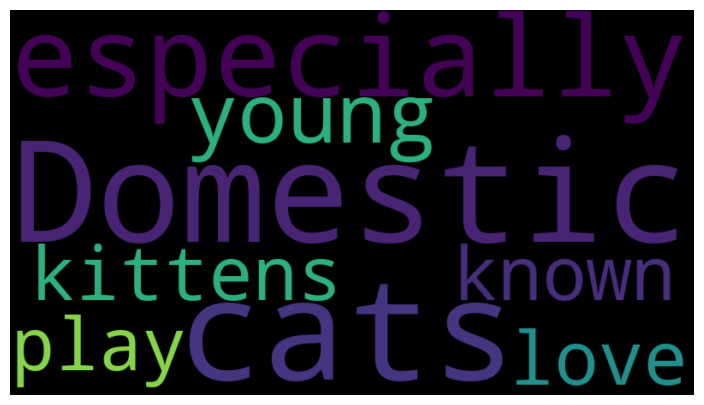

In [52]:
# word cloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

words = "Domestic cats, especially young kittens, are known for their love of play."
cloud = WordCloud(width=800, height=450, background_color="black").generate(words)

plt.figure(figsize=(9, 5))
plt.imshow(cloud, interpolation="bilinear")
plt.axis("off")
plt.show()